# Introduction to Dataset

- Sumber Dataset: [roboflow](https://universe.roboflow.com/sinica-dz08y/egg-4u31w)
- Alasan Pemilihan Data:
    - Data publik dan mudah diakses
    - Menunjang tujuan pribadi untuk mendalami computer vision

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import os
from roboflow import Roboflow
from dotenv import load_dotenv

load_dotenv()

True

# Load Dataset

In [2]:
# Get data from Roboflow
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("sinica-dz08y").project("egg-4u31w")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /mnt/d/object-counting/dataset//Egg-1 in yolov11:: 100%|██████████| 654/654 [00:03<00:00, 206.07it/s]


# Exploratory Data Analysis (EDA)

In [5]:
# Visualize some samples from the dataset
def visualize_dataset(split, num_samples=5):
    "Visualize random samples from the dataset split (train/valid/test)."
    split_dir = os.path.join(dataset.location, split, 'images')
    image_files = [f for f in os.listdir(split_dir) if f.endswith(('.jpg', '.png'))]
    sample_files = np.random.choice(image_files, num_samples, replace=False)
    for img_file in sample_files:
        img_path = os.path.join(split_dir, img_file)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"{split} - {img_file}")
        plt.axis('off')
        plt.show()

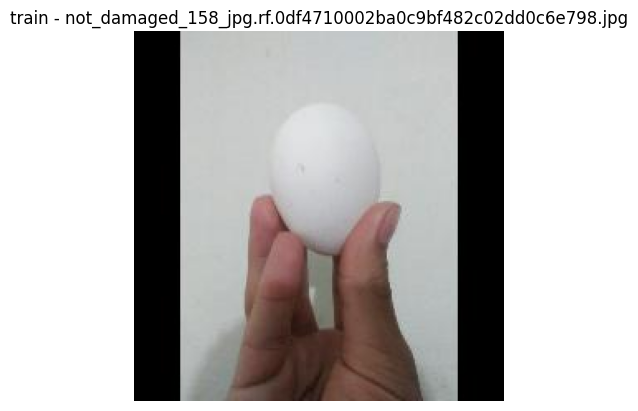

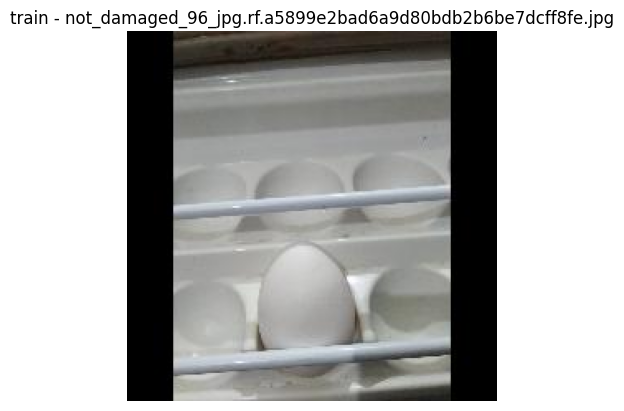

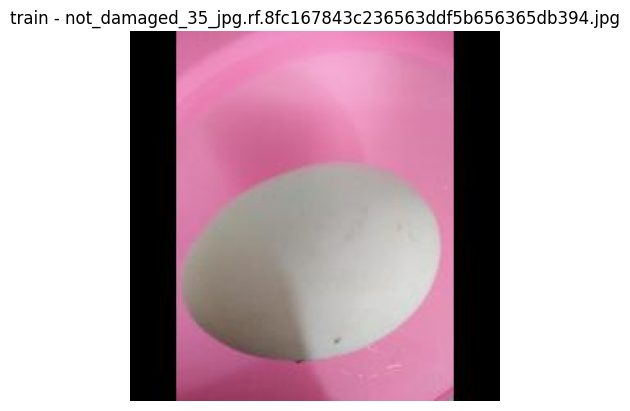

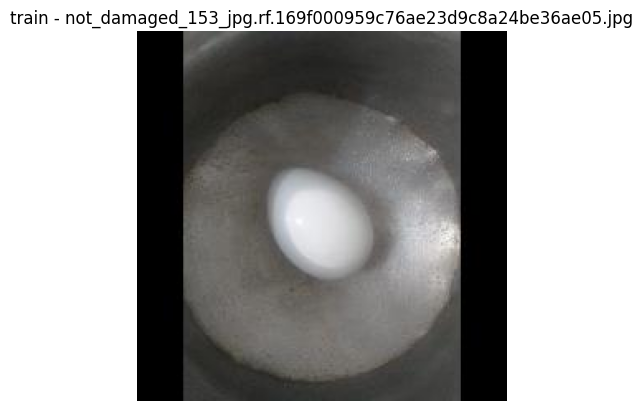

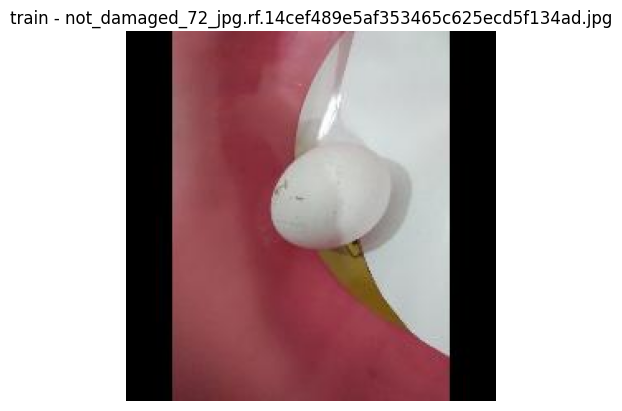

In [6]:
visualize_dataset('train')

In [7]:
# Check image extensions
splits = ['train', 'valid', 'test']
extensions = {split: set() for split in splits}

for split in splits:
    split_dir = os.path.join(dataset.location, split, 'images')
    for img_file in os.listdir(split_dir):
        if img_file.endswith(('.jpg', '.png')):
            ext = os.path.splitext(img_file)[1].lower()
            extensions[split].add(ext)

print("Image extensions in each split:")
for split, exts in extensions.items():
    print(f"{split}: {exts}")

Image extensions in each split:
train: {'.jpg'}
valid: {'.jpg'}
test: {'.jpg'}


In [8]:
# Image distribution

for split in splits:
    split_dir = os.path.join(dataset.location, split, 'images')
    num_images = len(os.listdir(split_dir))
    print(f"{split}: {num_images} images")

train: 272 images
valid: 33 images
test: 16 images


# Data Preprocessing